# 25-psoriasis-2

In [1]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import re
import warnings
warnings.filterwarnings('ignore')
from data.cell_type import annotate_cells
from data.loading import read_sample

DATA = Path("data")

/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
Matplotlib is building the font cache; this may take a moment.
/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
SAMPLE_RE = re.compile(r"PSA(.+)")

adatas_gex = {}
adatas_airr = {}

for sample_dir in sorted(DATA.glob("*")):
  if not sample_dir.is_dir():
    continue

  match = SAMPLE_RE.fullmatch(sample_dir.name)
  if not match:
    continue

  sample = sample_dir.name
  patient = match.group(1)

  gex, airr = read_sample(sample_dir)

  for adata in (gex, airr):
    adata.obs["sample"] = sample
    adata.obs["patient"] = patient

  adatas_gex[sample] = gex
  adatas_airr[sample] = airr

adata_gex = ad.concat(adatas_gex, index_unique="_")
adata_airr = ad.concat(adatas_airr, index_unique="_")

mdata = mu.MuData({
  "gex": adata_gex,
  "airr": adata_airr,
})

mdata


MuData object with n_obs × n_vars = 36433 × 13100
  2 modalities
    gex:	34393 × 13100
      obs:	'sample', 'hashtag', 'tissue', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'patient'
      layers:	None
    airr:	24151 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient'
      obsm:	'airr', 'chain_indices'

In [3]:
mdata['gex'].layers['counts'] = mdata['gex'].X.copy()
sc.pp.normalize_total(mdata['gex'], target_sum=1e4)
sc.pp.log1p(mdata['gex'])
sc.pp.neighbors(mdata['gex'])
sc.tl.umap(mdata['gex'])

In [4]:
mu.pp.filter_obs(mdata['gex'], 'sample', lambda sample: sample != "PSA3b")
mu.pp.filter_obs(mdata['airr'], 'sample', lambda sample: sample != "PSA3b")
mdata.update()

In [5]:
annotate_cells(mdata)

🔬 Input data has 32566 cells and 13100 genes
🔗 Matching reference genes in the model
🧬 4250 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


MuData object with n_obs × n_vars = 34544 × 13100
  2 modalities
    gex:	32566 × 13100
      obs:	'sample', 'hashtag', 'tissue', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'patient', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
      uns:	'log1p', 'pca', 'neighbors', 'umap', 'over_clustering'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None, 'counts'
      obsp:	'distances', 'connectivities'
    airr:	22818 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient'
      obsm:	'airr', 'chain_indices'

... storing 'sample' as categorical
... storing 'patient' as categorical


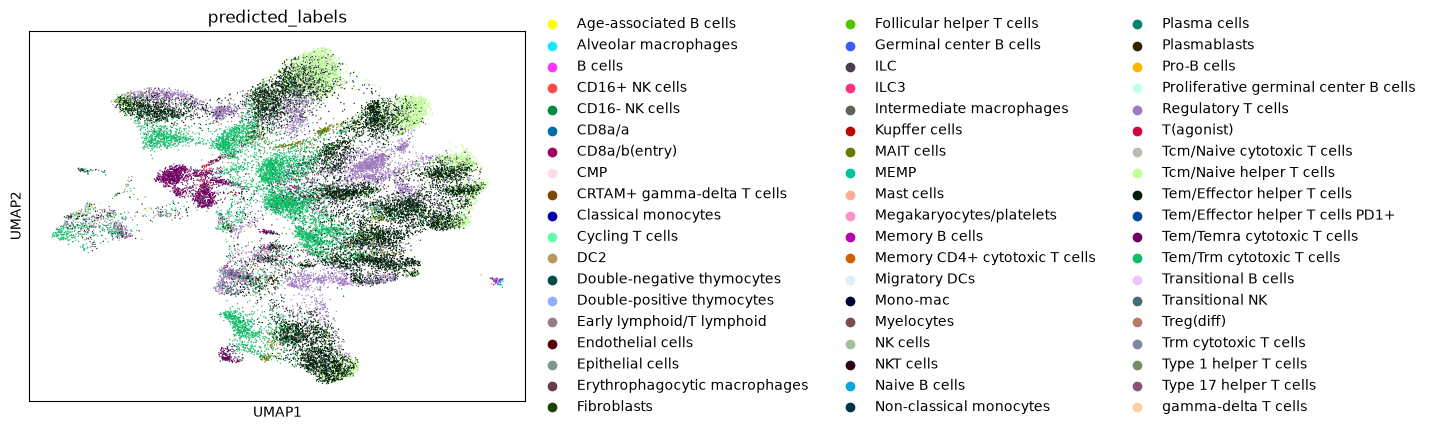

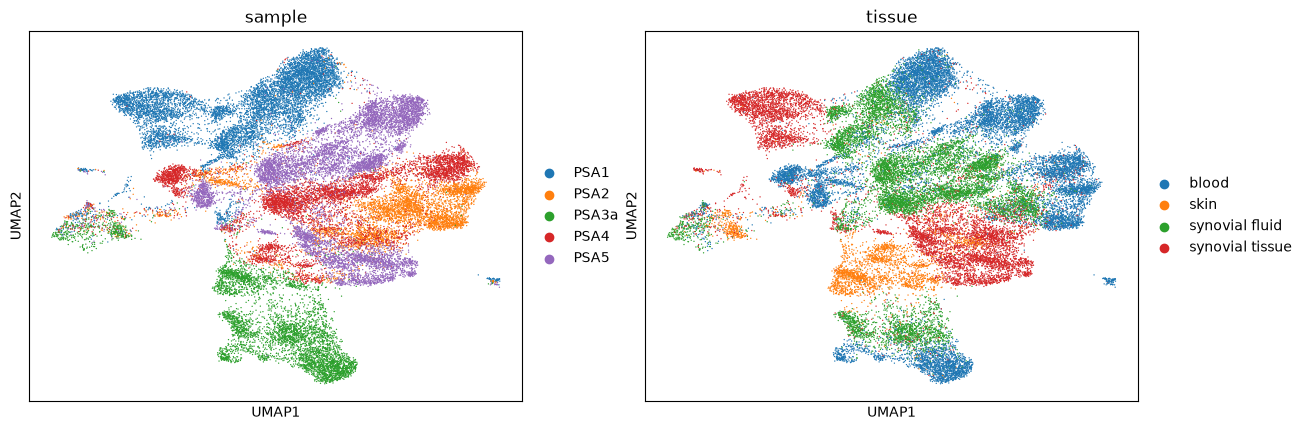

In [6]:
sc.pl.umap(
  mdata['gex'],
  color=["predicted_labels"],
)

sc.pl.umap(
  mdata['gex'],
  color=["sample", "tissue"],
)

In [7]:
mdata["gex"].obs["predicted_labels"].value_counts()

predicted_labels
Tem/Effector helper T cells              12560
Tem/Trm cytotoxic T cells                 6749
Regulatory T cells                        4920
Tcm/Naive helper T cells                  4252
Tem/Temra cytotoxic T cells               1995
MAIT cells                                 586
Type 1 helper T cells                      325
Type 17 helper T cells                     152
Trm cytotoxic T cells                      129
Tcm/Naive cytotoxic T cells                123
CRTAM+ gamma-delta T cells                  93
Follicular helper T cells                   84
Proliferative germinal center B cells       68
CD16+ NK cells                              60
Naive B cells                               51
Memory B cells                              48
NKT cells                                   41
NK cells                                    39
Plasmablasts                                34
Memory CD4+ cytotoxic T cells               31
Treg(diff)                                 

In [8]:
mdata["airr"].obs["chain_pairing"].value_counts()

chain_pairing
single pair    22818
Name: count, dtype: int64

In [9]:
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")

mdata

MuData object with n_obs × n_vars = 34544 × 13100
  2 modalities
    gex:	32566 × 13100
      obs:	'sample', 'hashtag', 'tissue', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'patient', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
      uns:	'log1p', 'pca', 'neighbors', 'umap', 'over_clustering', 'predicted_labels_colors', 'sample_colors', 'tissue_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None, 'counts'
      obsp:	'distances', 'connectivities'
    airr:	22818 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'clone_id', 'clone_id_size'
      uns:	'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'

In [10]:
ir.pp.ir_dist(
  mdata,
  metric="tcrdist",
  sequence="aa",
  cutoff=15,
)

ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")

ir.tl.clonotype_network(mdata, min_cells=3, sequence="aa", metric="tcrdist")

... storing 'gex:sample' as categorical
... storing 'gex:patient' as categorical
... storing 'airr:receptor_type' as categorical
... storing 'airr:receptor_subtype' as categorical
... storing 'airr:chain_pairing' as categorical
... storing 'airr:sample' as categorical
... storing 'airr:patient' as categorical
... storing 'airr:clone_id' as categorical
... storing 'airr:cc_aa_tcrdist' as categorical
... storing 'receptor_type' as categorical
... storing 'receptor_subtype' as categorical
... storing 'chain_pairing' as categorical
... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'clone_id' as categorical
... storing 'cc_aa_tcrdist' as categorical


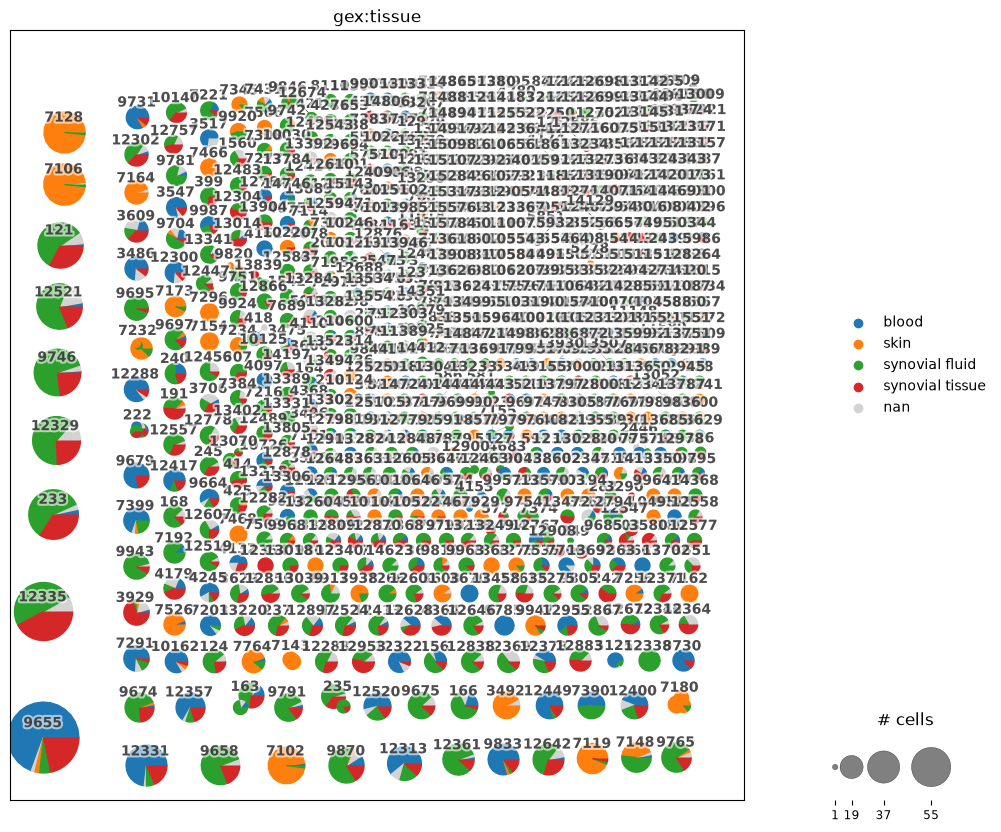

In [11]:
_ = ir.pl.clonotype_network(mdata, color="gex:tissue")

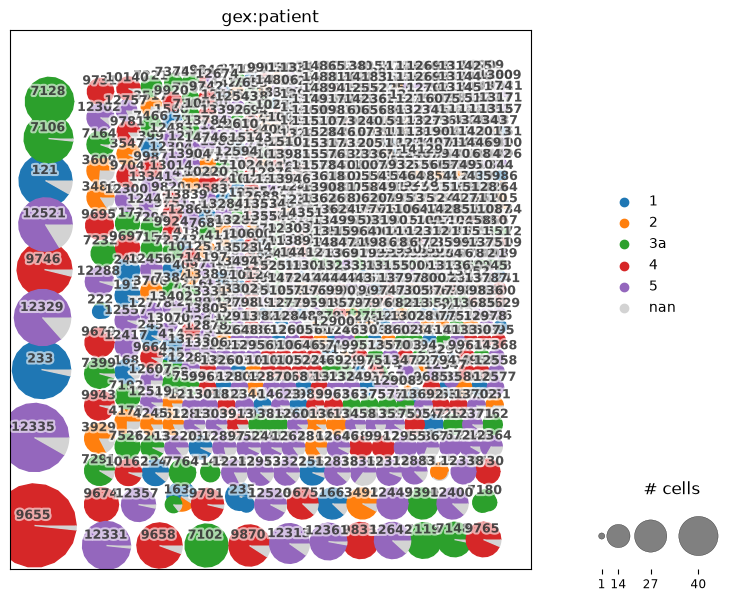

In [12]:
_ = ir.pl.clonotype_network(mdata, color="gex:patient", label_fontsize=9, panel_size=(7, 7), base_size=20)

In [13]:
obs = mdata.obs

pd.crosstab(obs['gex:patient'], obs['gex:tissue']).T

gex:patient,1,2,3a,4,5
gex:tissue,,,,,
blood,3133,2276,1927,2032,2982
skin,31,233,1463,917,0
synovial fluid,2519,1056,1783,2194,2596
synovial tissue,2444,1333,155,906,2586


In [14]:
p3 = obs[obs["gex:patient"] == "3a"]
p3 = p3[p3["airr:patient"] == "3a"]

p3.head()

,gex:sample,gex:hashtag,gex:tissue,gex:n_genes,gex:n_genes_by_counts,gex:log1p_n_genes_by_counts,gex:total_counts,gex:log1p_total_counts,gex:pct_counts_in_top_50_genes,gex:pct_counts_in_top_100_genes,...,gex:conf_score,airr:receptor_type,airr:receptor_subtype,airr:chain_pairing,airr:sample,airr:patient,airr:clone_id,airr:clone_id_size,airr:cc_aa_tcrdist,airr:cc_aa_tcrdist_size
AAACCTGAGCGTCAAG-1_PSA3a,PSA3a,AHH05,skin,775,775,6.654153,1435,7.269617,33.658537,45.505226,...,0.786134,TCR,TRA+TRB,single pair,PSA3a,3a,7151,1.0,7097,1.0
AAACCTGCAGGTCCAC-1_PSA3a,PSA3a,AHH04,synovial fluid,1058,1054,6.961296,2092,7.646354,31.357553,43.690249,...,0.370340,TCR,TRA+TRB,single pair,PSA3a,3a,7152,2.0,7098,2.0
AAACCTGCAGTAACGG-1_PSA3a,PSA3a,AHH04,synovial fluid,1440,1440,7.273093,4062,8.309677,36.459872,50.910881,...,0.998821,TCR,TRA+TRB,single pair,PSA3a,3a,7153,2.0,7099,2.0
AAACCTGGTAGCACGA-1_PSA3a,PSA3a,AHH02,blood,1334,1334,7.196687,4133,8.327001,41.785628,56.399710,...,0.838082,TCR,TRA+TRB,single pair,PSA3a,3a,7154,1.0,7100,1.0
AAACCTGGTGCGATAG-1_PSA3a,PSA3a,AHH06,synovial tissue,1318,1318,7.184629,3679,8.210668,36.640391,51.128024,...,0.996903,TCR,TRA+TRB,single pair,PSA3a,3a,7155,6.0,7101,6.0


In [23]:
def tissue_clonotype_share(mdata, *tissues):
  obs = mdata.obs

  clones = {
    t: set(obs.loc[obs["gex:tissue"] == t, "airr:clone_id"].dropna())
    for t in tissues
  }
  shared_clones = set.intersection(*clones.values())

  total_clones = obs["airr:clone_id"].nunique()
  label = "/".join(tissues)

  print(f"{label} shared clones: {len(shared_clones) / total_clones}")
  for t in tissues:
    others = "/".join(o for o in tissues if o != t)
    print(f"{t} shares clones with {others}: {len(shared_clones) / len(clones[t])}")

  return shared_clones

def filter_patient(mdata: mu.MuData, patient: str) -> mu.MuData:
  mdata = mdata.copy()
  mu.pp.filter_obs(mdata, 'airr:patient', lambda x: x == patient)
  mu.pp.intersect_obs(mdata)
  return mdata

In [16]:
mdata_1 = filter_patient(mdata, "1")
mdata_3 = filter_patient(mdata, "3a")
mdata_4 = filter_patient(mdata, "4")
mdata_5 = filter_patient(mdata, "5")

In [19]:
print("=== PATIENT 1 ===")
tissue_clonotype_share(mdata_1, "blood", "synovial fluid")
print("=== PATIENT 4 ===")
tissue_clonotype_share(mdata_4, "blood", "synovial fluid")
print("=== PATIENT 5 ===")
tissue_clonotype_share(mdata_5, "blood", "synovial fluid")

=== PATIENT 1 ===
blood/synovial fluid shared_clones: 0.013460963206700568
blood shares clones with synovial fluid: 0.028517110266159697
synovial fluid shares clones with blood: 0.04186046511627907
=== PATIENT 4 ===
blood/synovial fluid shared_clones: 0.02017850213426465
blood shares clones with synovial fluid: 0.054110301768990635
synovial fluid shares clones with blood: 0.053169734151329244
=== PATIENT 5 ===
blood/synovial fluid shared_clones: 0.021457085828343315
blood shares clones with synovial fluid: 0.047226798462383306
synovial fluid shares clones with blood: 0.07319148936170213


In [ ]:
print("=== PATIENT 3 ===")
tissue_clonotype_share(mdata_3, "skin", "synovial fluid")
print("")
tissue_clonotype_share(mdata_3, "skin", "synovial tissue")
print("")
p3_shared_synovial_skin = tissue_clonotype_share(mdata_3, "skin", "synovial tissue", "synovial fluid")

=== PATIENT 3 ===
skin/synovial fluid shared clones: 0.01985413290113452
skin shares clones with synovial fluid: 0.11666666666666667
synovial fluid shares clones with skin: 0.04994903160040775

skin/synovial tissue shared clones: 0.0016207455429497568
skin shares clones with synovial tissue: 0.009523809523809525
synovial tissue shares clones with skin: 0.044444444444444446

skin/synovial tissue/synovial fluid shared clones: 0.0008103727714748784
skin shares clones with synovial tissue/synovial fluid: 0.004761904761904762
synovial tissue shares clones with skin/synovial fluid: 0.022222222222222223
synovial fluid shares clones with skin/synovial tissue: 0.0020387359836901123


In [ ]:
airr = mdata["airr"]
cells = airr.obs_names[airr.obs["clone_id"].isin(p3_shared_synovial_skin)]

seqs = ir.get.airr(
    airr[cells],
    ["junction_aa", "v_call", "j_call"],
    ["VJ_1", "VDJ_1", "VJ_2", "VDJ_2"],
)
seqs.insert(0, "clone_id", airr.obs.loc[cells, "clone_id"])

seqs.drop_duplicates().sort_values("clone_id")


,clone_id,VJ_1_junction_aa,VJ_1_v_call,VJ_1_j_call,VDJ_1_junction_aa,VDJ_1_v_call,VDJ_1_j_call,VJ_2_junction_aa,VJ_2_v_call,VJ_2_j_call,VDJ_2_junction_aa,VDJ_2_v_call,VDJ_2_j_call
cell_id,,,,,,,,,,,,,
AAAGATGCATTGCGGC-1_PSA3a,7173,CAENTGGFKTIF,TRAV25,TRAJ9,CATRTPDPVNEQFF,TRBV15,TRBJ2-1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
AGCATACGTTCCGTCT-1_PSA3a,7572,CAASYNQGGKLIF,TRAV13-1,TRAJ23,CASSAGPNYEQYF,TRBV7-6,TRBJ2-7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [33]:
iggytop = ir.datasets.iggytop()

ir.pp.ir_dist(mdata, iggytop, metric="identity", sequence="aa")

ir.tl.ir_query(
    mdata,
    iggytop,
    metric="identity",
    sequence="aa",
    receptor_arms="any",
    dual_ir="any",
)

ir.tl.ir_query_annotate(
    mdata,
    iggytop,
    metric="identity",
    sequence="aa",
    include_ref_cols=["antigen_species"],
    strategy="most-frequent",
)

  0%|          | 0/5212 [00:00<?, ?it/s]

In [56]:
shared_blood_synovial = tissue_clonotype_share(mdata, "blood", "synovial tissue", "synovial fluid")

shared_blood_synovial

blood/synovial tissue/synovial fluid shared clones: 0.006193998436466414
blood shares clones with synovial tissue/synovial fluid: 0.014916727009413468
synovial tissue shares clones with blood/synovial fluid: 0.0287950796757059
synovial fluid shares clones with blood/synovial tissue: 0.020833333333333332


{'100',
 '10067',
 '10363',
 '10366',
 '10682',
 '10809',
 '121',
 '12395',
 '12406',
 '12424',
 '12444',
 '12450',
 '12454',
 '12461',
 '12471',
 '12493',
 '12502',
 '12506',
 '12510',
 '12542',
 '12603',
 '12614',
 '12615',
 '12618',
 '12702',
 '12723',
 '12737',
 '12743',
 '12767',
 '12856',
 '12862',
 '12874',
 '12894',
 '12905',
 '12944',
 '12966',
 '12993',
 '13053',
 '13114',
 '13320',
 '13322',
 '13335',
 '13372',
 '13400',
 '13443',
 '13672',
 '13788',
 '13795',
 '13995',
 '14173',
 '15222',
 '15263',
 '1538',
 '156',
 '163',
 '166',
 '180',
 '233',
 '234',
 '240',
 '249',
 '273',
 '314',
 '35',
 '3503',
 '36',
 '3637',
 '3657',
 '3734',
 '3755',
 '3957',
 '419',
 '4209',
 '4275',
 '479',
 '593',
 '7',
 '7155',
 '7272',
 '7278',
 '7348',
 '7599',
 '7602',
 '7811',
 '8049',
 '960',
 '9735',
 '9744',
 '9754',
 '9765',
 '9777',
 '9784',
 '9804',
 '9805',
 '9826',
 '9871',
 '9885',
 '9913',
 '9926',
 '9943',
 '9950',
 '9975',
 '9977'}

In [57]:
obs = mdata.obs
obs = obs[obs["airr:clone_id"].isin(shared_blood_synovial)]
obs.value_counts("airr:antigen_species", dropna=False)

airr:antigen_species
NaN                                                1394
Severe acute respiratory syndrome coronavirus 2      82
ambiguous                                            63
Influenza A virus                                    29
Homo sapiens                                         24
Epstein-Barr virus                                   22
Cytomegalovirus                                      21
Homo sapiens immunodeficiency virus 1                12
Name: count, dtype: int64

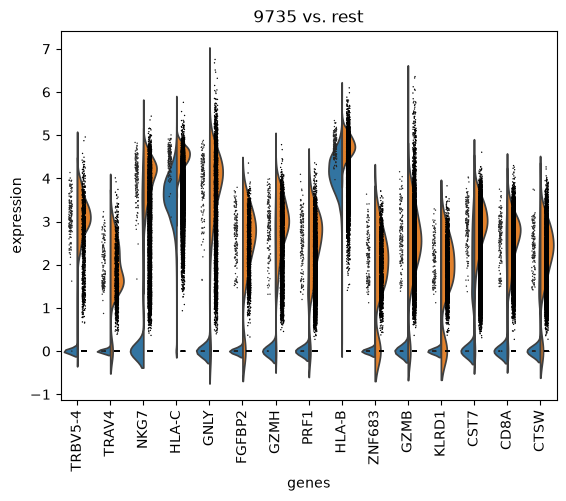

In [58]:
largest_clone_id = obs.sort_values("airr:clone_id_size", ascending=False).iloc[0]["airr:clone_id"]

with ir.get.obs_context(mdata["gex"], {"clone_id": mdata.obs["airr:clone_id"]}) as tmp_ad:
    sc.tl.rank_genes_groups(tmp_ad, "clone_id", groups=[largest_clone_id], method="wilcoxon")
    sc.pl.rank_genes_groups_violin(tmp_ad, groups=largest_clone_id, n_genes=15)